# Лабораторная работа №2: Классификация *kNN*

Автор: Федорова Софья Александровна, 6401-010302D

Датасет Pre-owner cars предоставляет исчерпывающую информацию о подержанных автомобилях, доступных в Индии. Он предлагает ценные инсайты для исследователей, аналитиков и компаний, работающих в автомобильной отрасли, особенно для тех, кто интересуется тенденциями рынка подержанных автомобилей, ценами и предпочтениями клиентов. Целевой признак - цена автомобиля.

Ссылка на датасет: https://www.kaggle.com/datasets/mrmars1010/cars-india-pre-owned

In [425]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs
import scipy.stats
import  plotly
from matplotlib.ticker import ScalarFormatter

## 1. Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.

### Считывание датасета из csv-файла

In [426]:
file = 'pre-owned_cars.csv'

df = pd.read_csv(file)

## 2. Бинарная классификация

#### Привести описание датасета.


  
   | Признак | Тип признака | Описание | Единицы измерения |   
   | --- | --- | --- | --- | 
   | brand | categorical | Марка или производитель автомобиля |  
   | model | categorical | Конкретная модель автомобиля| 
   | transmission | categorical | Тип трансмиссии | **целевой признак в задачах бинарной классификации**
   | make_year | categorical |Год производства автомобиля | 
   | reg_year | categorical | Год регистрации автомобиля | 
   | fuel_type  | categorical | Тип топлива, используемого автомобилем | **целевой признак в задачах многоклассовой классификации**
   | engine_capacity(CC) | quantitative | Объём двигателя в кубических сантиметрах | sm**3
   | km_driven | quantitative | Общее расстояние, которое автомобиль прошёл | km
   | ownership | categorical | Количество предыдущих владельцев автомобиля | 
   | **price** | **quantitative** | **Запрашиваемая цена за машину** | какая-то валюта (целевой признак в задаче регрессии)
   | overall_cost | quantitative  | Издержки |
   | has_insurance | categorical | Наличие страховки на машину |
   | spare_key | categorical | Наличие запасного ключа | 
   | reg_number | categorical | Регистрационный номер | 
   | title  | categorical | Краткая информация о машине (марка, год выпуска, бренд) |



In [427]:
df.head(3)

,brand,model,transmission,make_year,reg_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,overall_cost,has_insurance,spare_key,reg_number,title
0,Mahindra,Thar LX D 4WD MT CONVERTIBLE,Manual,2020.0,01-01-2021,Diesel,2184.0,11003.0,1st owner,1231000,23431.0,True,No,HR26,2020 Mahindra Thar LX D 4WD MT CONVERTIBLE
1,Hyundai,Verna 1.6 VTVT SX,Manual,2018.0,01-07-2018,Petrol,1591.0,66936.0,1st owner,786000,15359.0,True,No,DL7C,2018 Hyundai Verna 1.6 VTVT SX
2,Tata,Harrier XT PLUS 2.0L KRYOTEC DARK EDITON,Manual,2022.0,01-08-2022,Diesel,1956.0,27990.0,1st owner,1489000,28349.0,True,No,HR29,2022 Tata Harrier XT PLUS 2.0L KRYOTEC DARK ED...


#### Осуществить предобработку данных (избавиться от null, убрать некоторые признаки и т.п.) – "подчистить данные".

In [428]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2806 entries, 0 to 2805
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2805 non-null   object 
 1   model                2805 non-null   object 
 2   transmission         2805 non-null   object 
 3   make_year            2805 non-null   float64
 4   reg_year             720 non-null    object 
 5   fuel_type            2805 non-null   object 
 6   engine_capacity(CC)  2688 non-null   float64
 7   km_driven            2805 non-null   float64
 8   ownership            2805 non-null   object 
 9   price                2806 non-null   int64  
 10  overall_cost         2805 non-null   float64
 11  has_insurance        2805 non-null   object 
 12  spare_key            2805 non-null   object 
 13  reg_number           2805 non-null   object 
 14  title                2805 non-null   object 
dtypes: float64(4), int64(1), object(10)
me

Год регистрации автомобиля `reg_year` коррелирует с годом выпуска, поэтому можно избавиться от этого столбца.

Также столбец `title` дублирует информацию, хранящуюся в таблице (title = make_year + brand + model), поэтому его тоже удалим.

In [429]:
df.drop(columns=['reg_year', 'title'], inplace=True)

In [430]:
df.describe() # статистика по числовым столбцам

,make_year,engine_capacity(CC),km_driven,price,overall_cost
count,2805.000000,2688.000000,2805.000000,2.806000e+03,2805.000000
mean,2018.181105,1259.027530,49215.477362,1.342522e+06,13495.022816
std,2.945293,254.504798,26626.932696,3.554669e+07,6040.809220
min,2010.000000,624.000000,450.000000,1.630000e+05,4039.000000
25%,2016.000000,1194.000000,28540.000000,4.350000e+05,9267.000000
50%,2018.000000,1197.000000,45695.000000,5.940000e+05,12145.000000
75%,2021.000000,1462.000000,68182.000000,8.140000e+05,15760.000000
max,2024.000000,2694.000000,143991.000000,1.883558e+09,47338.000000


In [ ]:
df = df.dropna()

In [432]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2688 entries, 0 to 2804
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2688 non-null   object 
 1   model                2688 non-null   object 
 2   transmission         2688 non-null   object 
 3   make_year            2688 non-null   float64
 4   fuel_type            2688 non-null   object 
 5   engine_capacity(CC)  2688 non-null   float64
 6   km_driven            2688 non-null   float64
 7   ownership            2688 non-null   object 
 8   price                2688 non-null   int64  
 9   overall_cost         2688 non-null   float64
 10  has_insurance        2688 non-null   object 
 11  spare_key            2688 non-null   object 
 12  reg_number           2688 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 294.0+ KB


#### Закодировать категориальные признаки при необходимости.

In [433]:
numeric_cols =  ['price', 'km_driven', 'engine_capacity(CC)', 'make_year', 'overall_cost']
categorial_cols = ['brand', 'model', 'transmission', 'fuel_type', 'ownership', 'has_insurance', 'spare_key', 'reg_number']

df_categorial = df[categorial_cols]
df_categorial['model'].value_counts().sort_index() #категория model содержит 785 уникальных значений
df_categorial['brand'].value_counts().sort_index() #категория brand содержит 15 уникальных значений
df_categorial['transmission'].value_counts().sort_index() #категория transmission содержит 2 уникальных значения
df_categorial['fuel_type'].value_counts().sort_index() #категория transmission содержит 3 уникальных значения

df_categorial['ownership'].value_counts().sort_index() #категория ownership содержит 3 уникальных значения
df_categorial['has_insurance'].value_counts().sort_index() #категория transmission содержит только True
df_categorial['spare_key'].value_counts().sort_index() #категория ownership содержит 2 уникальных значения (No-1962, Yes-726)
df_categorial['reg_number'].value_counts().sort_index(); #категория reg_number содержит 153 уникальных значения

В результате анализа уникальных значений для категориальных признаков, удаляем признак has_insurance, содержащий только значения одного класса. Целевым классом в задаче классификации будет `transmission`.

In [434]:
df = df.drop(columns='has_insurance');

В датасете категория spare_key содержит 2 уникальных значения (No-1962, Yes-726), а значит есть дисбаланс. Избавимся от дисбаланса, используя взвешенное кодирование.

In [435]:
# Присваиваем веса обратно пропорционально частоте
weights = {
    'No': len(df) / (2 * df['spare_key'].value_counts()['No']),  # ~0.68
    'Yes': len(df) / (2 * df['spare_key'].value_counts()['Yes'])  # ~1.84
}

df['spare_key_weighted'] = df['spare_key'].map(weights)
print(f"Weighted encoding:\n{df['spare_key_weighted'].value_counts()}")

Weighted encoding:
spare_key_weighted
0.685015    1962
1.851240     726
Name: count, dtype: int64


Теперь категориальный признак `spare_key` перешёл в количественный `spare_key_weighted`, поэтому удаляем первый признак.

In [436]:
df = df.drop(columns='spare_key');

Для разных типов данных будем использовать разные способы кодирования признаков - для признаков с малым количеством категорий применяем `One-Hot Encoding`, для признаков с большим количеством категорий - `Label Encoding`.

При использовании One-Hot Encoding для признаков с большим количеством категорий (brand, model, reg_number) возникло бы увеличение размерности, то есть размерность стала бы содержать 961 признак. Для алгоритма kNN станет проблематично из-за "проклятия размерности" (расстояния в высокоразмерном пространстве становятся менее информативными).

In [437]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df_encoded = df.copy()

onehot_cols = ['transmission', 'fuel_type', 'ownership']
df_encoded = pd.get_dummies(df_encoded, columns=onehot_cols, drop_first=True)

label_cols = ['brand', 'model', 'reg_number']
label_encoders = {} # здесь хранится словарь с моделями для каждого столбца категориального признака

for col in label_cols:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    df_encoded.drop(col, axis=1, inplace=True)

df_encoded

,make_year,engine_capacity(CC),km_driven,price,overall_cost,spare_key_weighted,transmission_Manual,fuel_type_Diesel,fuel_type_Petrol,ownership_2nd owner,ownership_3rd owner,brand_encoded,model_encoded,reg_number_encoded
0,2020.0,2184.0,11003.0,1231000,23431.0,0.685015,True,True,False,False,False,7,631,35
1,2018.0,1591.0,66936.0,786000,15359.0,0.685015,True,False,True,False,False,3,678,22
2,2022.0,1956.0,27990.0,1489000,28349.0,0.685015,True,True,False,False,False,12,317,36
3,2023.0,1498.0,5061.0,1227000,23355.0,1.851240,False,False,True,False,False,2,131,19
4,2021.0,1498.0,23480.0,887000,16883.0,0.685015,True,True,False,False,False,1,208,142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2800,2013.0,1198.0,96363.0,213000,5614.0,1.851240,True,False,True,True,False,2,79,96
2801,2018.0,1497.0,46982.0,661000,12920.0,1.851240,False,False,True,False,False,1,214,98
2802,2015.0,1199.0,38706.0,412000,8057.0,1.851240,True,False,True,True,False,2,335,96
2803,2016.0,1197.0,31405.0,496000,9704.0,1.851240,True,False,True,False,False,3,226,98


Выбрать какое-нибудь значение гиперпараметра *k* алгоритма *kNN*.

In [438]:
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

In [439]:
from sklearn.model_selection import train_test_split
y = df_encoded['transmission_Manual']

df_encoded.drop(columns='transmission_Manual', inplace=True)

X = df_encoded

X.shape, y.shape

((2688, 13), (2688,))

#### Разбить выборку на обучающую и тестовую.

In [440]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.75, random_state=42
)

#### Осуществить бинарную классификацию.

In [441]:
model_knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean')

In [442]:
y_pred = model_knn.predict(X_test)

#### Посчитать метрики: *accuracy, precision, recall, f-measure*, а также составить *classification_report*.



In [443]:
import sklearn
accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)
precision = sklearn.metrics.precision_score(y_test, y_pred)
recall = sklearn.metrics.recall_score(y_test, y_pred)
f_measure = 2*(precision*recall)/(precision+recall)

print(f'Test accuracy: {accuracy}')
print(f'Test precision: {precision}')
print(f'Test recall: {recall}')
print(f'Test f-measure: {f_measure}')


Test accuracy: 0.6696428571428571
Test precision: 0.7325581395348837
Test recall: 0.8181818181818182
Test f-measure: 0.7730061349693251


In [444]:
report = sklearn.metrics.classification_report(y_test, y_pred, target_names=["Automatic", "Manual"])
print(report)

              precision    recall  f1-score   support

   Automatic       0.46      0.34      0.39       210
      Manual       0.73      0.82      0.77       462

    accuracy                           0.67       672
   macro avg       0.60      0.58      0.58       672
weighted avg       0.65      0.67      0.65       672



Нормализовать данные (StandardScalerили MinMaxScaler).

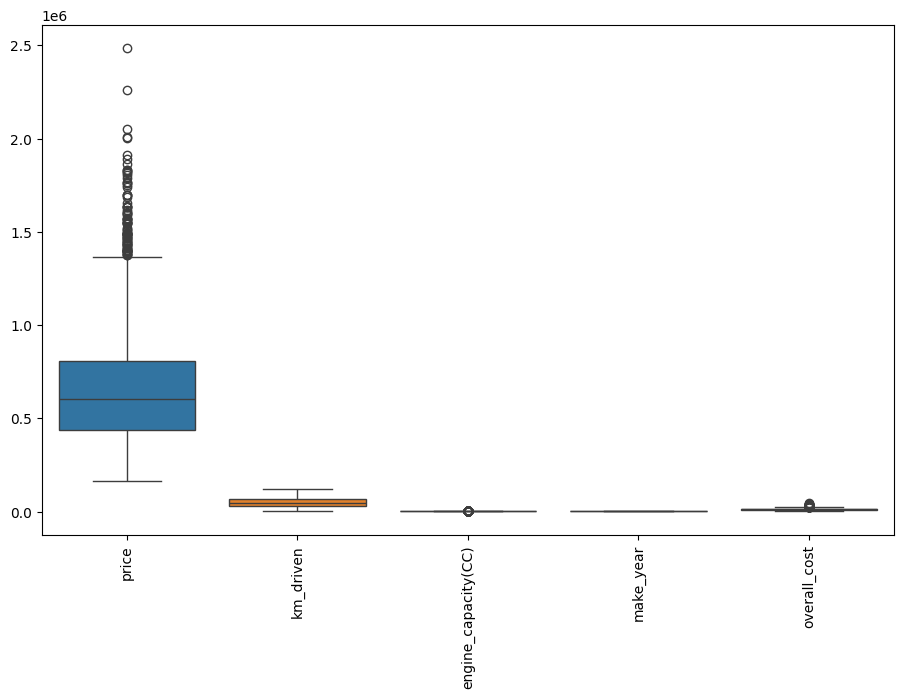

In [445]:
import copy
import seaborn as sns

fig, ax = plt.subplots(figsize=(11, 7.5))
sns.boxplot(data = X_train[numeric_cols], ax = ax)
plt.subplots_adjust(bottom=0.2)
plt.xticks(rotation=90)
plt.show()

In [446]:
X_train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,2016.0,666307.043651,319658.152503,163000.0,435000.00,602500.0,810000.0,2487000.0
km_driven,2016.0,49493.730159,26788.928656,1343.0,28796.25,46045.5,68922.5,123296.0
engine_capacity(CC),2016.0,1258.086806,251.285027,624.0,1197.00,1197.0,1462.0,2694.0
make_year,2016.0,2018.148810,2.938861,2010.0,2016.00,2018.0,2021.0,2024.0
overall_cost,2016.0,13416.921627,5827.208644,4039.0,9297.75,12234.0,15720.5,47338.0


In [447]:
from sklearn.preprocessing import StandardScaler
X_train_norm = X_train.copy()

scaler = StandardScaler()
scaler.fit(X_train[numeric_cols])

X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [448]:
X_train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,2016.0,1.260015e-16,1.000248,-1.574907,-0.723787,-0.199660,0.449632,5.697163
km_driven,2016.0,1.286449e-16,1.000248,-1.797858,-0.772805,-0.128750,0.725434,2.755638
engine_capacity(CC),2016.0,-3.656687e-16,1.000248,-2.524003,-0.243158,-0.243158,0.811683,5.715699
make_year,2016.0,-3.685324e-14,1.000248,-2.773466,-0.731352,-0.050648,0.970409,1.991466
overall_cost,2016.0,-4.493760e-17,1.000248,-1.609733,-0.707061,-0.203050,0.395412,5.822598


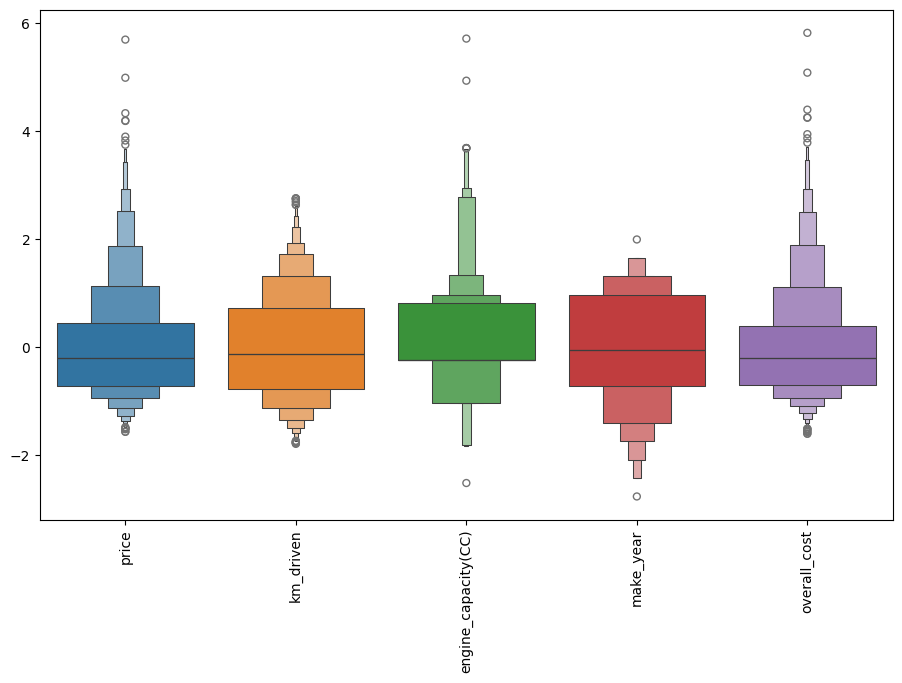

In [449]:
fig, ax = plt.subplots(figsize=(11, 7.5))
sns.boxenplot(data = X_train[numeric_cols], ax = ax)
plt.subplots_adjust(bottom=0.2)
plt.xticks(rotation=90)
plt.show()

#### Осуществить бинарную классификацию.

In [450]:
model_knn.fit(X_train, y_train)
y_pred_norm = model_knn.predict(X_test)

In [451]:
import sklearn
accuracy_norm = sklearn.metrics.accuracy_score(y_test, y_pred_norm)
precision_norm = sklearn.metrics.precision_score(y_test, y_pred_norm)
recall_norm = sklearn.metrics.recall_score(y_test, y_pred_norm)
f_measure_norm = 2*(precision_norm*recall_norm)/(precision_norm+recall_norm)

print(f'Test accuracy: {accuracy_norm}')
print(f'Test precision: {precision_norm}')
print(f'Test recall: {recall_norm}')
print(f'Test f-measure: {f_measure_norm}')

norm_report = sklearn.metrics.classification_report(y_test, y_pred_norm, target_names=["Automatic", "Manual"])

Test accuracy: 0.6815476190476191
Test precision: 0.7470119521912351
Test recall: 0.8116883116883117
Test f-measure: 0.7780082987551868


Сравнить метрики на данных без нормализации и с применением нормализации.

In [452]:
print(f'Test accuracy: {accuracy}')
print(f'Test precision: {precision}')
print(f'Test recall: {recall}')
print(f'Test f-measure: {f_measure} \n')

print(f'Test normalizated data accuracy: {accuracy_norm}')
print(f'Test normalizated data precision: {precision_norm}')
print(f'Test normalizated data recall: {recall_norm}')
print(f'Test normalizated data f-measure: {f_measure_norm}')

Test accuracy: 0.6696428571428571
Test precision: 0.7325581395348837
Test recall: 0.8181818181818182
Test f-measure: 0.7730061349693251 

Test normalizated data accuracy: 0.6815476190476191
Test normalizated data precision: 0.7470119521912351
Test normalizated data recall: 0.8116883116883117
Test normalizated data f-measure: 0.7780082987551868


In [453]:
print(report)

print(norm_report)

              precision    recall  f1-score   support

   Automatic       0.46      0.34      0.39       210
      Manual       0.73      0.82      0.77       462

    accuracy                           0.67       672
   macro avg       0.60      0.58      0.58       672
weighted avg       0.65      0.67      0.65       672

              precision    recall  f1-score   support

   Automatic       0.49      0.40      0.44       210
      Manual       0.75      0.81      0.78       462

    accuracy                           0.68       672
   macro avg       0.62      0.60      0.61       672
weighted avg       0.67      0.68      0.67       672



Как мы можем заметить, значения для точности, полноты, f1-меры улучшились в результате нормализации данных.

Построить `сorrelation heatmap` и/или воспользоваться методом `corr()`. Выбрать наиболее важные признаки эвристически или на основании каких-нибудь вычислений

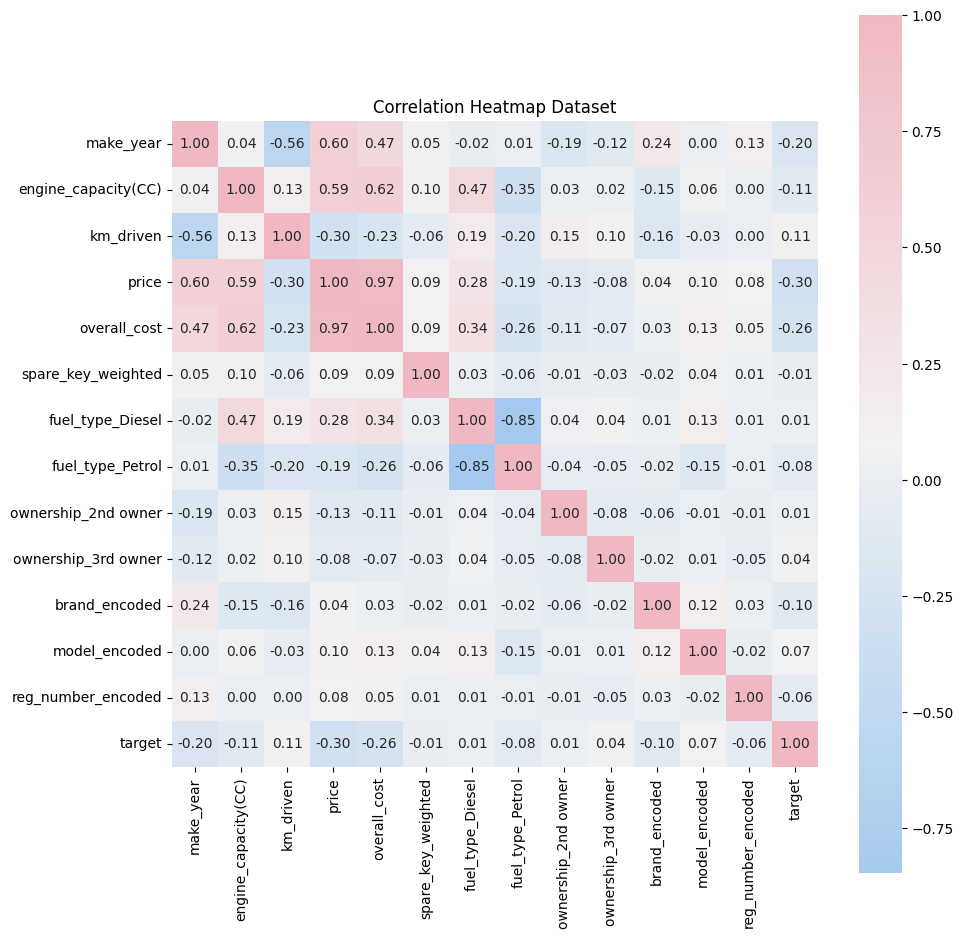

In [454]:
import matplotlib.pyplot as plt
import seaborn as sns

data = df_encoded
data['target'] = y

fig, ax = plt.subplots(figsize=(10, 10))
plt.title('Correlation Heatmap Dataset')
cmap = sns.diverging_palette(240, 0, s=70, l=80, as_cmap=True)
ax_sns = sns.heatmap(ax = ax, data=data.corr(), cmap=cmap, square=True, annot=True, fmt='.2f', linecolor='white')
ax_sns.set_yticklabels(ax_sns.get_yticklabels(), rotation=0)
plt.subplots_adjust(bottom=0.15)
fig.tight_layout()
plt.show()

Возращаясь к признакам целевым в задаче бинарной классификации является тип трансмиссии (механическая или автоматическая коробка передач).

Тип трансмиссии влияет на стоимость автомобиля, предполагалось, что и обратная зависимость существует. Корреляционная матрица подтверждает эту связь: **рост цены** → падение вероятности Manual → рост вероятности Automatic.
В первой лабораторной работе было отмечено, что *overall_cost тесно коррелирует с ценой*, поэтому от это признака мы можем избавиться.

Заметная связь существует между годом выпуска и целевой переменной, т.к. новые машины чаще автоматические.

Также существует умеренная связь между пробегом и коробкой передач, т.к. машины с большим пробегом чаще механические (старые модели).

Таким образом, значимыми для нас признаками остаются `price`, `make_year`, `km_driven`, а также `engine_capacity(CC)`, остальные параметры создают больше шума для модели, подвергая ее переобучению.

In [455]:
important_features = ['make_year', 'engine_capacity(CC)', 'km_driven', 'price'] 

In [456]:
X_train = X_train[important_features]
X_test = X_test[important_features]

Осуществить бинарную классификацию с отфильтрованными признаками.

In [457]:
model_knn.fit(X_train, y_train)
y_predict = model_knn.predict(X_test)

In [458]:
import sklearn
accuracy = sklearn.metrics.accuracy_score(y_test, y_predict)
precision = sklearn.metrics.precision_score(y_test, y_predict)
recall = sklearn.metrics.recall_score(y_test, y_predict)
f_measure = 2*(precision*recall)/(precision+recall)

print(f'Test accuracy: {accuracy}')
print(f'Test precision: {precision}')
print(f'Test recall: {recall}')
print(f'Test f-measure: {f_measure}')

report = sklearn.metrics.classification_report(y_test, y_predict, target_names=["Automatic", "Manual"])

Test accuracy: 0.7098214285714286
Test precision: 0.7643564356435644
Test recall: 0.8354978354978355
Test f-measure: 0.798345398138573


In [459]:
print(norm_report)

print(report)


              precision    recall  f1-score   support

   Automatic       0.49      0.40      0.44       210
      Manual       0.75      0.81      0.78       462

    accuracy                           0.68       672
   macro avg       0.62      0.60      0.61       672
weighted avg       0.67      0.68      0.67       672

              precision    recall  f1-score   support

   Automatic       0.54      0.43      0.48       210
      Manual       0.76      0.84      0.80       462

    accuracy                           0.71       672
   macro avg       0.65      0.63      0.64       672
weighted avg       0.70      0.71      0.70       672



Значения для точности, полноты, f1-меры повысились в результате избавления от не значимых признаков, создающих шум.

Перебрать значения гиперпараметра *k* в каком-нибудь диапазоне с использованием кросс-валидации на данных – исходных данных до разбиения с применением нормализации с отфильтрованными признаками. Построить график train/test accuracy в зависимости от значения k.

In [460]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


In [461]:
X = df_encoded[important_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.75, random_state=42
)

In [462]:
neighbors_settings = range(1, 16) 

train_accuracy_cv = [] 
test_accuracy_fixed = [] 

for n_neighbors in neighbors_settings:
    knn_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=n_neighbors, metric='euclidean'))
    ])
    
    scores = cross_val_score(knn_pipeline, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    train_accuracy_cv.append(mean_score)

    knn_pipeline.fit(X_train, y_train)
    test_acc = knn_pipeline.score(X_test, y_test)
    test_accuracy_fixed.append(test_acc)


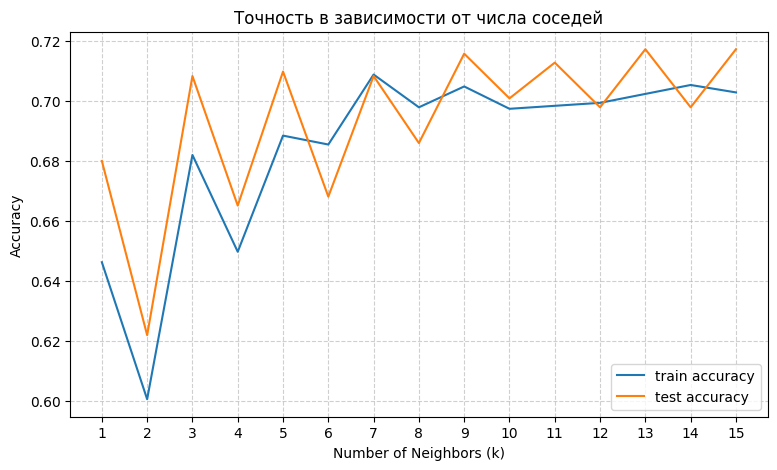

In [463]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(neighbors_settings, train_accuracy_cv, label="train accuracy")
ax.plot(neighbors_settings, test_accuracy_fixed, label="test accuracy")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Number of Neighbors (k)")
ax.set_xticks(range(1, 16))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_title(f"Точность в зависимости от числа соседей")

plt.show()

## Многоклассовая классификация.

Привести описание датасета.


Для многоклассовой классификации используется тот же дата сет про машины, где целевой признак - `fuel_type`.

In [464]:
file = 'pre-owned_cars.csv'

df = pd.read_csv(file)

Осуществить предобработку данных – "подчистить данные".

In [465]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2806 entries, 0 to 2805
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2805 non-null   object 
 1   model                2805 non-null   object 
 2   transmission         2805 non-null   object 
 3   make_year            2805 non-null   float64
 4   reg_year             720 non-null    object 
 5   fuel_type            2805 non-null   object 
 6   engine_capacity(CC)  2688 non-null   float64
 7   km_driven            2805 non-null   float64
 8   ownership            2805 non-null   object 
 9   price                2806 non-null   int64  
 10  overall_cost         2805 non-null   float64
 11  has_insurance        2805 non-null   object 
 12  spare_key            2805 non-null   object 
 13  reg_number           2805 non-null   object 
 14  title                2805 non-null   object 
dtypes: float64(4), int64(1), object(10)
me

Удалим столбец `reg_year`, который несет информацию о годе регистрации автомобиля, потому что информация не так важна, как год производства, и содержит большое количество пропущенных значений. Также удалим столбец `has_insurance`, поскольку кроме значения `True` этот столбец не содержит.

Также столбец `title` дублирует информацию, хранящуюся в таблице (title = make_year + brand + model), поэтому его тоже удалим.

In [466]:
df = df.drop(columns=['reg_year', 'has_insurance', 'title'])

И удалим строки, содержащие пустые элементы.

In [467]:
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2688 entries, 0 to 2804
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2688 non-null   object 
 1   model                2688 non-null   object 
 2   transmission         2688 non-null   object 
 3   make_year            2688 non-null   float64
 4   fuel_type            2688 non-null   object 
 5   engine_capacity(CC)  2688 non-null   float64
 6   km_driven            2688 non-null   float64
 7   ownership            2688 non-null   object 
 8   price                2688 non-null   int64  
 9   overall_cost         2688 non-null   float64
 10  spare_key            2688 non-null   object 
 11  reg_number           2688 non-null   object 
dtypes: float64(4), int64(1), object(7)
memory usage: 273.0+ KB


Закодировать категориальные признаки при необходимости.

Для разных типов данных будем использовать разные способы кодирования признаков - для признаков с малым количеством категорий применяем `One-Hot Encoding`, для признаков с большим количеством категорий - `Label Encoding`.


При использовании One-Hot Encoding для признаков с большим количеством категорий (brand, model, reg_number) возникло бы увеличение размерности, то есть размерность стала бы содержать 961 признак. Для алгоритма kNN станет проблематично из-за "проклятия размерности" (расстояния в высокоразмерном пространстве становятся менее информативными).
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [468]:
df_encoded = df.copy()

onehot_cols = ['transmission', 'ownership', 'spare_key']
df_encoded = pd.get_dummies(df_encoded, columns=onehot_cols, drop_first=True)

label_cols = ['brand', 'model', 'reg_number', 'fuel_type']
label_encoders = {} # здесь хранится словарь с моделями для каждого столбца категориального признака

for col in label_cols:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    df_encoded.drop(col, axis=1, inplace=True)

print(dict(enumerate(label_encoders['fuel_type'].classes_)))

{0: 'CNG', 1: 'Diesel', 2: 'Petrol'}


Нормализовать данные.

In [469]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = ['make_year', 'engine_capacity(CC)', 'km_driven', 'price', 'overall_cost']

scaler.fit(df_encoded[numeric_cols])

df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])


Выбрать какое-нибудь значение гиперпараметра *k* алгоритма *kNN*.

In [470]:
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=3)

Разбить выборку на обучающую и тестовую.

In [471]:
df_encoded['fuel_type_encoded'].value_counts()

fuel_type_encoded
2    2286
1     300
0     102
Name: count, dtype: int64

In [472]:
y = df_encoded['fuel_type_encoded']
df_filtered = df_encoded.drop(columns='fuel_type_encoded')
X = df_filtered

df_filtered

,make_year,engine_capacity(CC),km_driven,price,overall_cost,transmission_Manual,ownership_2nd owner,ownership_3rd owner,spare_key_Yes,brand_encoded,model_encoded,reg_number_encoded
0,0.629073,3.635077,-1.441171,1.700941,1.656558,True,False,False,False,7,631,35
1,-0.054138,1.304629,0.656857,0.351349,0.314775,True,False,False,False,3,678,22
2,1.312285,2.739053,-0.803994,2.483401,2.474061,True,False,False,False,12,317,36
3,1.653891,0.939145,-1.664053,1.688810,1.643924,False,False,False,True,2,131,19
4,0.970679,0.939145,-0.973163,0.657661,0.568104,True,False,False,False,1,208,142
...,...,...,...,...,...,...,...,...,...,...,...,...
2800,-1.762168,-0.239834,1.760653,-1.386440,-1.305106,True,True,False,True,2,79,96
2801,-0.054138,0.935215,-0.091611,-0.027750,-0.090652,False,False,False,True,1,214,98
2802,-1.078956,-0.235904,-0.402041,-0.782915,-0.899014,True,True,False,True,2,335,96
2803,-0.737350,-0.243764,-0.675899,-0.528160,-0.625238,True,False,False,True,3,226,98


In [473]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.75, random_state=42
)

При наличии дисбаланса классов снизить дисбаланс классов.

В нашей целевой переменной есть дисбаланс, который будем снижать с помощью метода `SMOTE`. Метод находит ближайших соседей миноритарного класса и генерирует образцы, делая линейную интерполяцию между ними. Обычно образец выбирается случайным образом из малочисленного класса. Это делается для того, чтобы обеспечить разнообразие и предотвратить смещение в сторону какой-либо конкретной области пространства признаков. 

In [474]:
print(y.value_counts(normalize=True).head(5))

fuel_type_encoded
2    0.850446
1    0.111607
0    0.037946
Name: proportion, dtype: float64


In [475]:
from imblearn.combine import SMOTETomek

# SMOTE + Tomek links (удаляет "шумные" образцы)
smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train, y_train)

print(pd.Series(y_train_resampled).value_counts().sort_index())

fuel_type_encoded
0    1673
1    1671
2    1633
Name: count, dtype: int64


Осуществить многоклассовую классификацию.

In [476]:
model_knn.fit(X_train_resampled, y_train_resampled)

y_pred_multiclass = model_knn.predict(X_test)

#### Посчитать метрики: *accuracy, precision, recall, f-measure*, а также составить *classification_report*.

In [477]:
import sklearn
accuracy = sklearn.metrics.accuracy_score(y_test, y_pred_multiclass)
precision = sklearn.metrics.precision_score(y_test, y_pred_multiclass, average='weighted')
recall = sklearn.metrics.recall_score(y_test, y_pred_multiclass, average='weighted')
f_measure = 2*(precision*recall)/(precision+recall)

print(f'Test accuracy: {accuracy}')
print(f'Test precision: {precision}')
print(f'Test recall: {recall}')
print(f'Test f-measure: {f_measure}')


Test accuracy: 0.7410714285714286
Test precision: 0.8292317539765219
Test recall: 0.7410714285714285
Test f-measure: 0.7826768325579796


In [478]:
# {0: 'CNG', 1: 'Diesel', 2: 'Petrol'}
report = sklearn.metrics.classification_report(y_test, y_pred_multiclass, target_names=["CNG", "Diesel", 'Petrol'], zero_division=0)
print(report)

              precision    recall  f1-score   support

         CNG       0.22      0.69      0.33        26
      Diesel       0.36      0.53      0.43        75
      Petrol       0.92      0.77      0.84       571

    accuracy                           0.74       672
   macro avg       0.50      0.67      0.53       672
weighted avg       0.83      0.74      0.77       672



Построить `сorrelation heatmap` и/или воспользоваться методом `corr()`. Выбрать наиболее важные признаки эвристически или на основании каких-нибудь вычислений

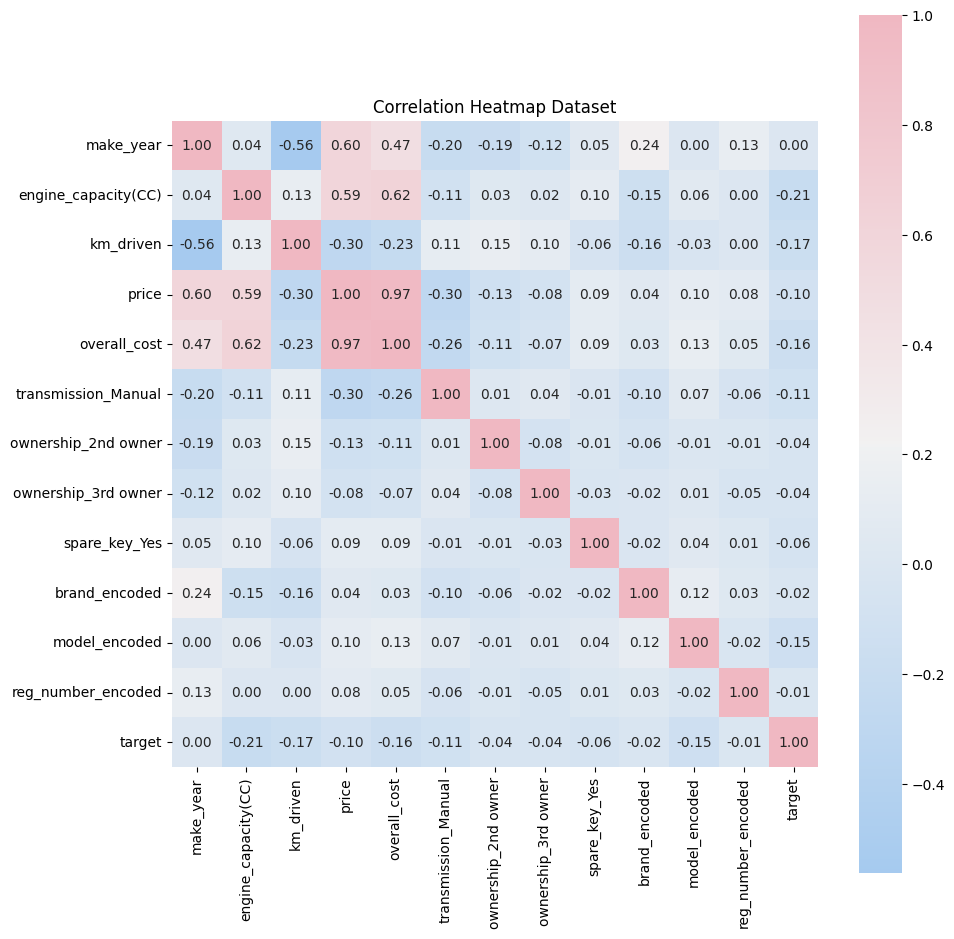

In [479]:
import matplotlib.pyplot as plt
import seaborn as sns

data = df_filtered
data['target'] = y

fig, ax = plt.subplots(figsize=(10, 10))
plt.title('Correlation Heatmap Dataset')
cmap = sns.diverging_palette(240, 0, s=70, l=80, as_cmap=True)
ax_sns = sns.heatmap(ax = ax, data=data.corr(), cmap=cmap, square=True, annot=True, fmt='.2f', linecolor='white')
ax_sns.set_yticklabels(ax_sns.get_yticklabels(), rotation=0)
plt.subplots_adjust(bottom=0.15)
fig.tight_layout()
plt.show()

Наша целевая переменная имеет выраженную корреляцию со следующими переменными `engine_capacity(CC)`, `km_driven`, `price`, `overall_cost`, `transmission_Manual`, `model_encoded`, именно их мы оставим.

Осуществить многоклассовую классификацию с отфильтрованными признаками.

In [480]:
target_columns = ['engine_capacity(CC)', 'km_driven', 'price', 'overall_cost', 'transmission_Manual', 'model_encoded']

In [481]:
model_knn.fit(X_train_resampled[target_columns], y_train_resampled)

y_multiclass = model_knn.predict(X_test[target_columns])

In [482]:
import sklearn
accuracy_multiclass = sklearn.metrics.accuracy_score(y_test, y_multiclass)
precision_multiclass = sklearn.metrics.precision_score(y_test, y_multiclass, average='weighted')
recall_multiclass = sklearn.metrics.recall_score(y_test, y_multiclass, average='weighted')
f_measure_multiclass = 2*(precision*recall)/(precision+recall)

print(f'Test accuracy: {accuracy_multiclass}')
print(f'Test precision: {precision_multiclass}')
print(f'Test recall: {recall_multiclass}')
print(f'Test f-measure: {f_measure_multiclass}')

Test accuracy: 0.8616071428571429
Test precision: 0.9153820412673842
Test recall: 0.8616071428571429
Test f-measure: 0.7826768325579796


In [483]:
# {0: 'CNG', 1: 'Diesel', 2: 'Petrol'}
report_multiclass = sklearn.metrics.classification_report(y_test, y_multiclass, target_names=["CNG", "Diesel", 'Petrol'], zero_division=0)

Сравнить результаты "до" и "после" фильтрации, сделать выводы.

In [484]:
print(report)

print(report_multiclass)

              precision    recall  f1-score   support

         CNG       0.22      0.69      0.33        26
      Diesel       0.36      0.53      0.43        75
      Petrol       0.92      0.77      0.84       571

    accuracy                           0.74       672
   macro avg       0.50      0.67      0.53       672
weighted avg       0.83      0.74      0.77       672

              precision    recall  f1-score   support

         CNG       0.27      0.73      0.39        26
      Diesel       0.67      0.80      0.73        75
      Petrol       0.98      0.88      0.92       571

    accuracy                           0.86       672
   macro avg       0.64      0.80      0.68       672
weighted avg       0.92      0.86      0.88       672



После фильтрации признаков значение метрики `precision` увеличилось для каждого из классов, это произошло из-за того, что мы избавились от внешнего шума, сократив число признаков вдвое. Остальные метрики тоже улучшились для каждого класса, особенно впечатляет значения `recall`, `f1-score` для класса `Diesel`, который находится в серьезном дисбалансе относительно мажоритарного класса. Большой вклад внесла также работа над дисбалансом классов в тренировочной выборке.

In [485]:
neighbors_settings = range(1, 16) 

train_accuracy_cv = [] 
test_accuracy_fixed = [] 

for n_neighbors in neighbors_settings:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric='euclidean')
    
    scores = cross_val_score(knn, X_train_resampled[target_columns], y_train_resampled, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    train_accuracy_cv.append(mean_score)

    knn.fit(X_train_resampled[target_columns], y_train_resampled)
    test_acc = knn.score(X_test[target_columns], y_test)
    test_accuracy_fixed.append(test_acc)


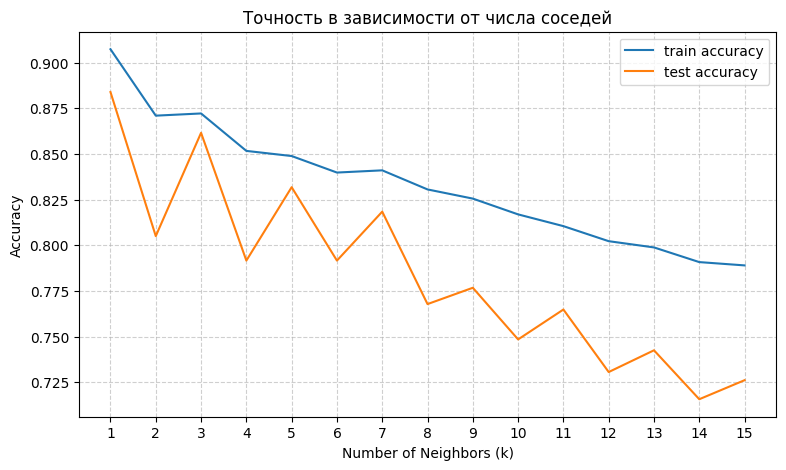

In [486]:
best_k_index = np.argmax(train_accuracy_cv)
best_k = neighbors_settings[best_k_index]
best_cv_score = train_accuracy_cv[best_k_index]
best_test_score = test_accuracy_fixed[best_k_index]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(neighbors_settings, train_accuracy_cv, label="train accuracy")
ax.plot(neighbors_settings, test_accuracy_fixed, label="test accuracy")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Number of Neighbors (k)")
ax.set_xticks(range(1, 16))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_title(f"Точность в зависимости от числа соседей")

plt.show()

Для лучшего классификатора привести метрики, classification_report, построить confusion matrix (это вроде матрицы TN /TP /FN /FP, только расширенной для многоклассовой классификации, чтобы понять, в какие стороны чаще ошибается классификатор).

In [487]:
model_knn = KNeighborsClassifier(n_neighbors=1)

model_knn.fit(X_train_resampled[target_columns], y_train_resampled)
y_best = model_knn.predict(X_test[target_columns])

In [488]:
# {0: 'CNG', 1: 'Diesel', 2: 'Petrol'}
best_report_multiclass = sklearn.metrics.classification_report(y_test, y_best, target_names=["CNG", "Diesel", 'Petrol'], zero_division=0)

In [489]:
print(best_report_multiclass)

              precision    recall  f1-score   support

         CNG       0.30      0.73      0.43        26
      Diesel       0.74      0.85      0.80        75
      Petrol       0.98      0.89      0.93       571

    accuracy                           0.88       672
   macro avg       0.67      0.83      0.72       672
weighted avg       0.92      0.88      0.90       672




Матрица ошибок (числа):
             Pred CNG  Pred Diesel  Pred Petrol
True CNG           19            1            6
True Diesel         5           64            6
True Petrol        39           21          511


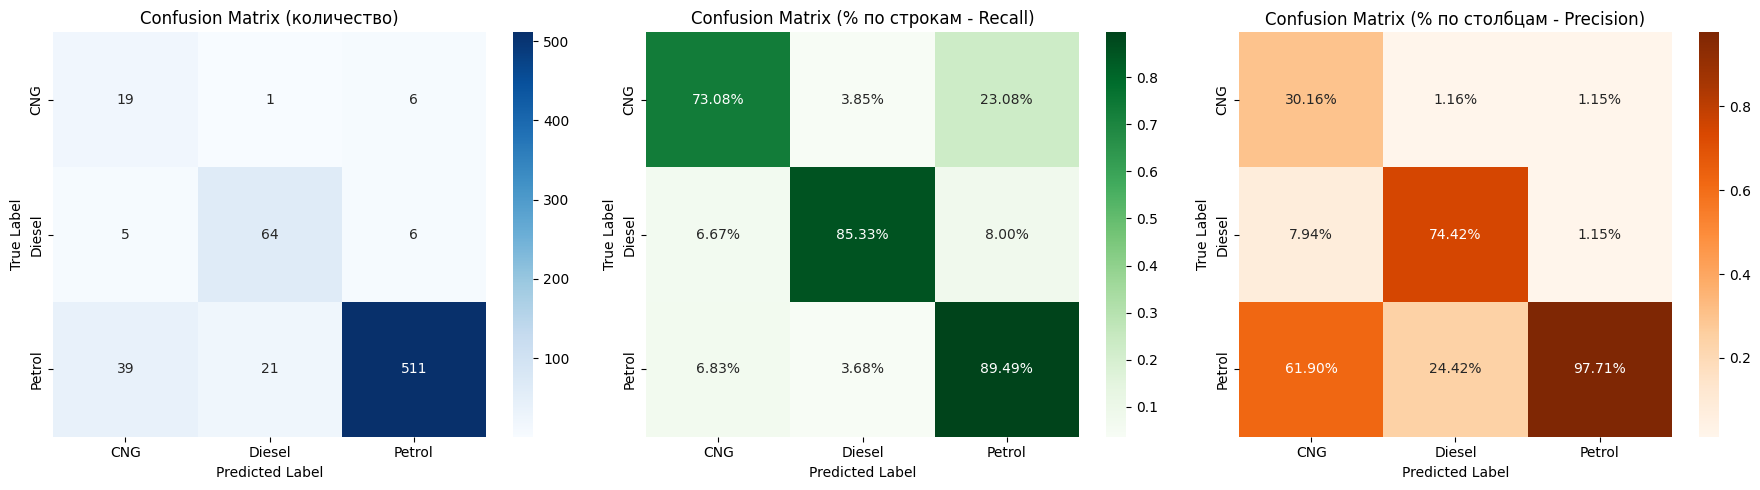

In [490]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_best)
target_names = ['CNG', 'Diesel', 'Petrol']

cm_df = pd.DataFrame(cm, 
                     index=[f'True {name}' for name in target_names],
                     columns=[f'Pred {name}' for name in target_names])
print("\nМатрица ошибок (числа):")
print(cm_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title('Confusion Matrix (количество)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_row_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_row_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title('Confusion Matrix (% по строкам - Recall)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

cm_col_norm = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :]
sns.heatmap(cm_col_norm, annot=True, fmt='.2%', cmap='Oranges', ax=axes[2],
            xticklabels=target_names, yticklabels=target_names)
axes[2].set_title('Confusion Matrix (% по столбцам - Precision)')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.tight_layout()
plt.show()